# Сегментация изображений подводных сцен

В этом домашнем задании вам предстоит обучить нейросеть для сегментации подводных сцен.

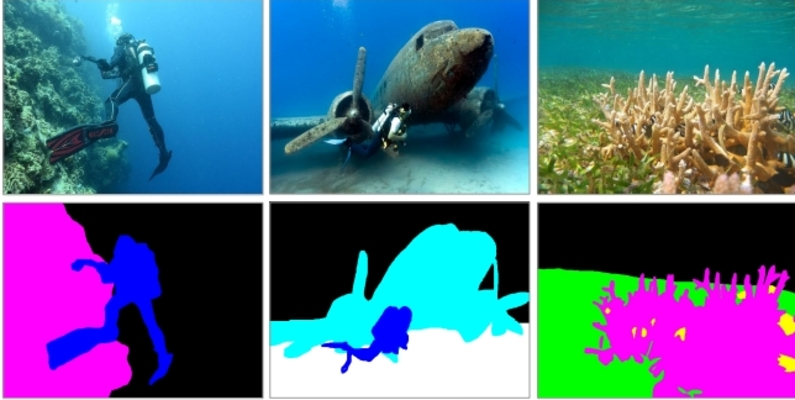

In [ ]:
from google.colab import drive
# Kaggle uses /kaggle/input for datasets and /kaggle/working for outputs

Drive already mounted at /kaggle/working; to attempt to forcibly remount, call drive.mount("/kaggle/working", force_remount=True).


## Подготовка датасета

#### Скачивание данных

Ячейки ниже скачивают и распаковывают данные

In [ ]:
! pip install wldhx.yadisk-direct

In [ ]:
! curl -L $(yadisk-direct https://disk.yandex.com/d/-93qaZ4NbYmwug) -o semantic-segmentation-of-underwater-imagery-suim.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  174M  100  174M    0     0  49.4M      0  0:00:03  0:00:03 --:--:-- 71.8M


In [ ]:
! unzip -qq semantic-segmentation-of-underwater-imagery-suim.zip


replace __MACOSX/._semantic-segmentation-of-underwater-imagery-suim? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


#### Загрузка датасета

Давайте поймем, как устроен наш датасет. Откроем несколько картинок и посмотрим на них.

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import os, zipfile, glob, random
import matplotlib.pyplot as plt
import cv2

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms


# фиксируем сиды
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

В папке semantic-segmentation-of-underwater-imagery-suim содержится две подпапки: train и test. В папке train лежат обучающие картинки (train/images) и их карты сегментации (train/masks). В папке test находятся картинки тестовой выборки, к которым карт сегментации нет. Ваша задача — обучить нейросеть на данных из train и получить предсказания для test. Эти предсказания нужно будет отправить в Я.Контест в качестве решения.

Классов сегментации всего 8:
- рыбы;
- рифы;
- морские растения;
- скалы/камни;
- дайверы (человеки);
- роботы;
- дно океана;
- все остальное (фон).

Откроем несколько картинок:

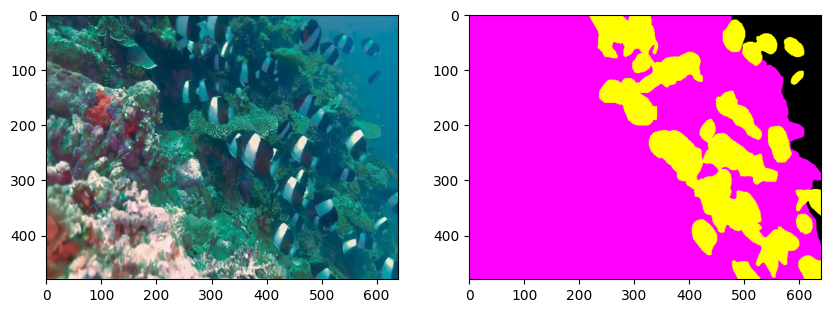

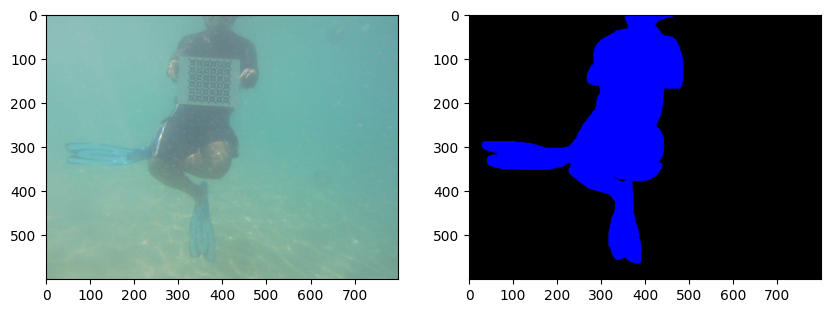

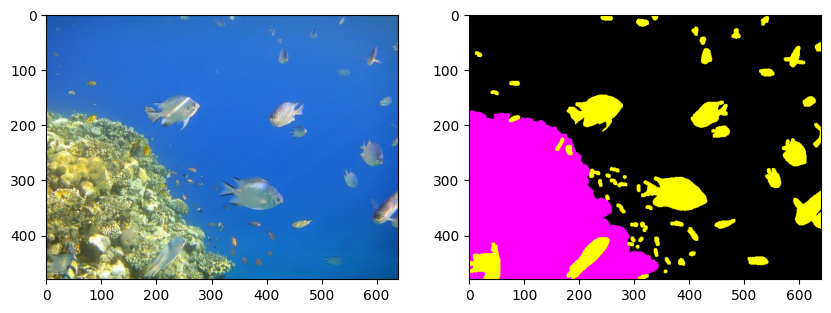

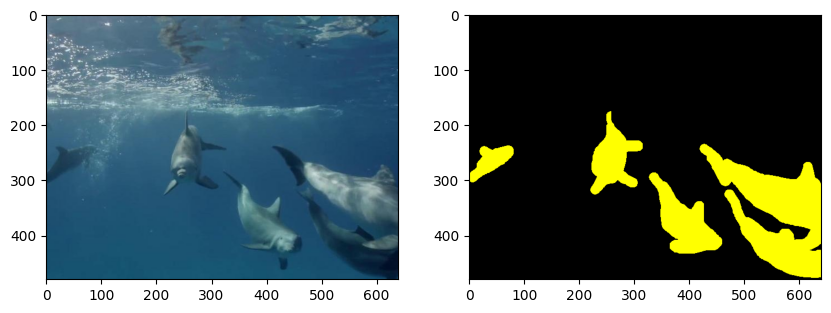

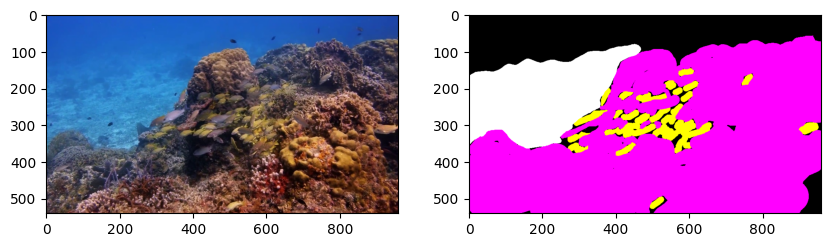

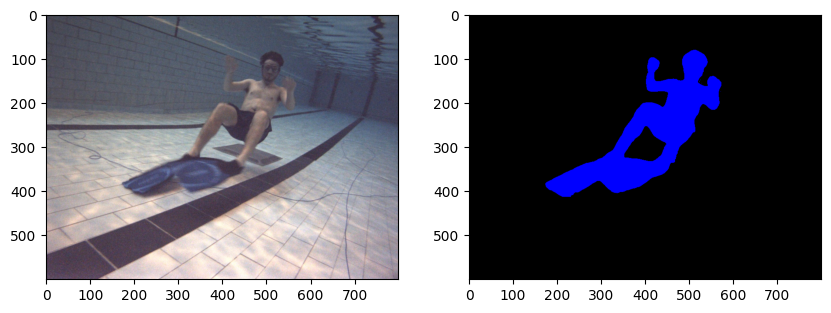

In [ ]:
img_names = os.listdir('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/')

for i, img_name in enumerate(img_names[:6]):
    # считываем картинку и ее карту сегментации
    img = plt.imread('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/'+ img_name)
    img_seg = plt.imread('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/'+ img_name[:-4]+'.bmp')

    # отрисовываем две картинки рядом друг с другом

    plt.figure(figsize=(10,8))

    plt.subplot(1,2,1)
    plt.imshow(img)

    plt.subplot(1,2,2)
    plt.imshow(img_seg)

Посмотрим, как устроена картинка-карта сегментации:

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
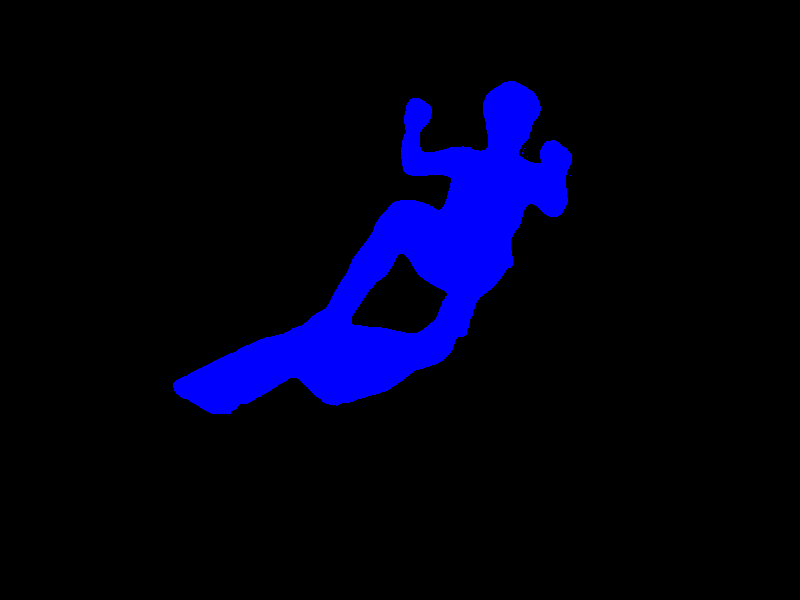

In [ ]:
img_seg

Как видим, в этот раз карты сегментации — это RGB-картинки. Пиксели разных классов имеют вид [0, 255, 255], [255 ,0, 0] и т.д.

Чтобы обучить нейросеть, нам нужно перевести карты сегментации в привычный вид — двумерный, где каждый пиксель имеет значение от 0 до 7 (т.е. значение пиксел я — это номер его класса). Сделать это нам поможет следующая функция:

In [ ]:
def preprocess_mask(mask):
    mask = (mask > 100)
    mask = np.dot(mask, [4,2,1]).astype(np.uint8)
    return mask

Применим функцию к одной маске сегментации:

In [ ]:
img_seg = plt.imread('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/d_r_162_.bmp')
new_img_seg = preprocess_mask(img_seg)
new_img_seg

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [7, 7, 7, ..., 7, 7, 7],
       [7, 7, 7, ..., 7, 7, 7],
       [7, 7, 7, ..., 7, 7, 7]], dtype=uint8)

Как видим, все полуичлось! На всякий случай выведем новую маску сегментации, чтобы убедиться, что она не сломалась:

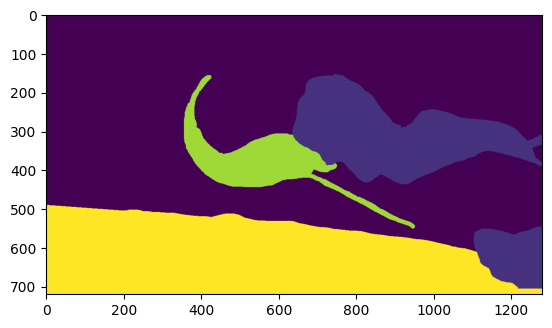

In [ ]:
plt.imshow(new_img_seg)

Теперь можно переходить к созданию датасета.

#### Создание Dataset

Для начала создадим два списка:
- список с путями до RGB картинок;
- список с путями до карт сегментаций этих картинок;

In [ ]:
images = []
segmentation_masks = []

for img_name in os.listdir('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/'):
    images.append('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/' + img_name)
    segmentation_masks.append('/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/' + img_name[:-4]+'.bmp')

In [ ]:
images[:5], segmentation_masks[:5]

(['/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/f_r_1129_.jpg',
  '/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/d_r_722_.jpg',
  '/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/f_r_1500_.jpg',
  '/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/f_r_661_.jpg',
  '/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/images/f_r_520_.jpg'],
 ['/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/f_r_1129_.bmp',
  '/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/d_r_722_.bmp',
  '/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/train_val/masks/f_r_1500_.bmp',
  '/kaggle/input/datasets/ashish2001/semantic-segmenta

Теперь создадим кастомный датасет torch.utils.data.Dataset для удобной работы c нашими данными в PyTorch.

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

In [ ]:
class UnderwaterDataset(Dataset):
    def __init__(self, images, segmentation_masks):

        self.images = images
        self.segmentation_masks = segmentation_masks

        self.images_transforms = transforms.Compose([
            transforms.Resize((256, 256)), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) # значения пикселей картинки нормализуются
        ])

        self.masks_transforms = transforms.Compose([
            # используем InterpolationMode.NEAREST, чтобы при изменении размера
            # маски сегментации не менялись номера классов
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
        ])

    def preprocess_mask(self, mask):
        mask = (np.array(mask) > 100)
        mask = np.dot(mask, [4,2,1]).astype(np.uint8)
        return Image.fromarray(mask)

    def __getitem__(self, index):
        '''
        этот метод должен по заданному номеру пары картинка-сегментация (index)
        возвращать эту пару. Этот метод обязательно нужно реализовывать во всех
        кастомных классах Dataset. Перед тем, как выдать на выходе
        пару картинка-сегментация, можно применить к картинкам любые преобразования:
        например, знакомую нам аугментацию.
        '''

        # загружаем нужные картинку и ее карту сегментации
        img = Image.open(self.images[index])
        mask = Image.open(self.segmentation_masks[index])

        # # применяем предобработку к RGB картинке
        img = self.images_transforms(img)
        # # применяем предобработку к маске сегментации
        mask = self.masks_transforms(self.preprocess_mask(mask))

        return (img, mask.squeeze()*255)

    def __len__(self):
        '''
        этот метод должен возвращать количество пар картинка-сегментация в датасете
        '''
        return len(self.images)

Проверим, что наш Dataset работает. Заведем переменную датасета и возьмем нулевой элемент. Отрисуем картинку и ее карту сегментации.

torch.Size([3, 256, 256]) torch.Size([256, 256])


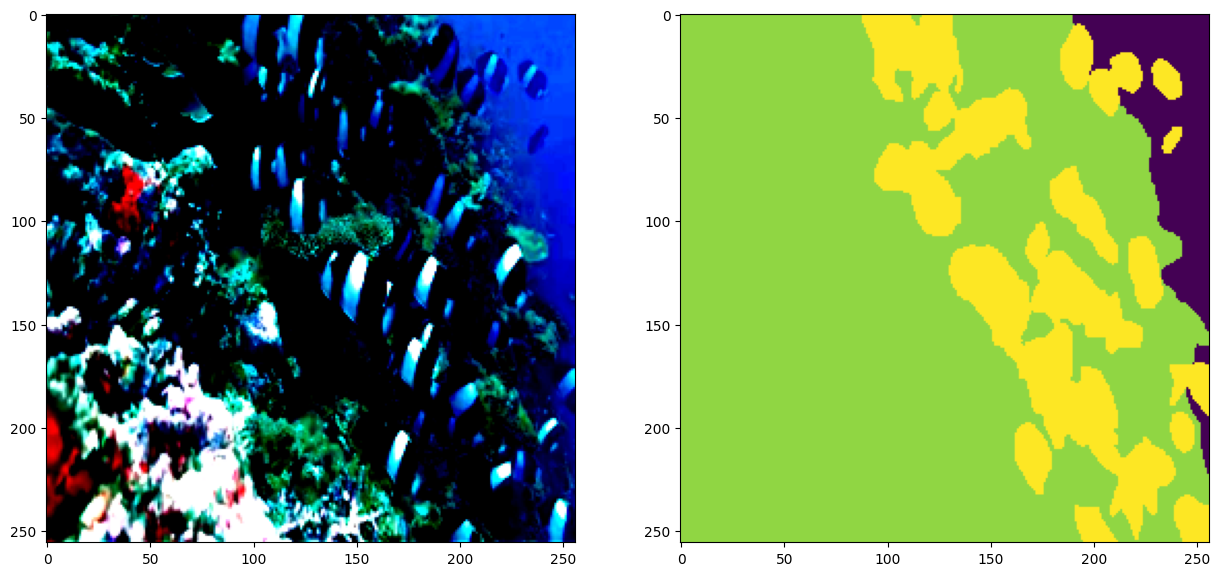

In [ ]:
dataset = UnderwaterDataset(images, segmentation_masks)

# dataset[0] — это вызов метода __getitem__(0)
img, mask = dataset[0]

print(img.shape, mask.shape)

# отрисовываем картинку
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(img.permute(1, 2, 0))
# отрисовываем маску
ax[1].imshow(mask.squeeze())
plt.show()

Готово! Разделим выборку на train и val:

In [ ]:
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

И заведем даталоадеры:

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=16, shuffle=True
)
val_loader = torch.utils.data.DataLoader(
    val_data, batch_size=16, shuffle=False
)


## Создание модели

Ваша задача — объявить и обучить модель, используя тренировочные и валидационные данные. Затем нужно получить предсказание на тестовых данных и отправить их в Я.Контест.

Ваши посылки будут оцениваться по метрике mIoU. Баллы будут ставиться следующим образом:
- 0 баллов, если mIoU < 0.4;
- 5 баллов, если 0.4 < mIoU < 0.5;
- 7.5 баллов, если 0.5 < mIoU < 0.6;
- 10 баллов, если mIoU > 0.6;

Какие идеи можно попробовать, чтобы получить больший скор:
- Обучить с нуля SegNet, UNet;
- Дообучить предобученную модель. Предобученные модели для сегментации можно использовать из библиотеки [segmentation_models_pytorch](https://github.com/qubvel/segmentation_models.pytorch)
- Для более эффективного обучения вам может пригодиться LR Scheduler для автоматической настройки learning rate в процесее обучения. [Вот тут](https://www.kaggle.com/code/isbhargav/guide-to-pytorch-learning-rate-scheduling) можно подробнее узнать про виды LR Scheduler и как использовать его в PyTorch
- Попробовать Dice Loss вместо CE;
- Аугментация данных. Обратите внимание, что мы решаем задачу сегментации, и если вы делаете с входящими картинками преобразования, которые меняют положение пикселей (shift/поворот/рястяжение и т.п.), то такое же преобразование нужно сделать и с соответствующей картой сегментации;
- Другие идеи, которые могут прийти вам в голову или можно найти в интернете =)

Ниже дан код, который может вам пригодиться для оценки качества вашей сети во время обучения:
- функция pixel_accuracy считает попиксельный accuracy между output (выход сети) и mask (верная карта сегментации);
- функция mIoU считает средний IoU по всем классам сегментации между output (выход сети) и mask (верная карта сегментации);

In [ ]:
def pixel_accuracy(output, mask):
    with torch.no_grad():
        output = torch.argmax(F.softmax(output, dim=1), dim=1)
        correct = torch.eq(output, mask).int()
        accuracy = float(correct.sum()) / float(correct.numel())
    return accuracy

def mIoU(pred_mask, mask, smooth=1e-10, n_classes=8):
    with torch.no_grad():
        pred_mask = F.softmax(pred_mask, dim=1)
        pred_mask = torch.argmax(pred_mask, dim=1)
        pred_mask = pred_mask.contiguous().view(-1)
        mask = mask.contiguous().view(-1)

        iou_per_class = []
        for clas in range(0, n_classes): #loop per pixel class
            true_class = pred_mask == clas
            true_label = mask == clas

            if true_label.long().sum().item() == 0: #no exist label in this loop
                iou_per_class.append(np.nan)
            else:
                intersect = torch.logical_and(true_class, true_label).sum().float().item()
                union = torch.logical_or(true_class, true_label).sum().float().item()

                iou = (intersect + smooth) / (union +smooth)
                iou_per_class.append(iou)
        return np.nanmean(iou_per_class)

In [ ]:
import torch, gc, sys, types

# 1) Попробуем выгрузить все модули/оптимизаторы из глобалей
for k, v in list(globals().items()):
    if isinstance(v, (torch.nn.Module, torch.optim.Optimizer)):
        globals().pop(k)
    # тензоры с grad (часто висят как временные)
    elif isinstance(v, torch.Tensor) and v.is_cuda:
        globals().pop(k)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()  # дополнительно чистит межпроцессные кэш-чанки


In [ ]:
import os, numpy as np, torch
from PIL import Image

def rgb_mask_to_index(arr_rgb):
    # тот же трюк, что в preprocess_mask: порог >100 по каждому каналу и кодирование 4*R + 2*G + 1*B
    bin3 = (arr_rgb > 100).astype(np.uint8)
    idx  = np.dot(bin3, [4,2,1]).astype(np.uint8)   # 0..7
    return idx

def compute_class_weights_from_rgb_masks(mask_paths, n_classes=8, eps=1e-6):
    counts = np.zeros(n_classes, dtype=np.int64)
    for p in mask_paths:
        if not str(p).lower().endswith((".png",".jpg",".bmp")):
            continue
        m = np.array(Image.open(p).convert("RGB"))
        idx = rgb_mask_to_index(m)
        # накопим частоты
        for c in range(n_classes):
            counts[c] += (idx == c).sum()
    freq = counts / (counts.sum() + eps)
    # median frequency balancing
    med = np.median(freq[freq > 0])
    weights = med / (freq + eps)
    return torch.tensor(weights, dtype=torch.float32)

# Пример использования:
# допустим, у тебя есть список путей train_masks (как в датасете)
class_weights = compute_class_weights_from_rgb_masks(segmentation_masks, n_classes=8).to(device)
print("class_weights:", class_weights)

# создаём лосс с весами (замени свой criterion на это)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)


class_weights: tensor([0.2146, 2.9616, 3.1849, 1.0328, 8.9637, 0.2026, 0.9692, 0.4907],
       device='cuda:0')


In [ ]:
# Берём предобученный backbone, меняем "голову" под 8 классов
model = torchvision.models.segmentation.deeplabv3_resnet50(weights="DEFAULT")
# у разных версий torchvision структура одинакова: последние слои — Conv2d(256, num_classes, 1)
model.classifier[-1] = nn.Conv2d(256, 8, kernel_size=1)
if model.aux_classifier is not None:
    model.aux_classifier[-1] = nn.Conv2d(256, 8, kernel_size=1)

model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)


In [ ]:
num_epochs = 3
best_miou = -1.0
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss, train_acc, train_miou = 0.0, 0.0, 0.0
    n_batches = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - train", leave=False):
        imgs = imgs.to(device)
        # твой датасет возвращает маски с числами 0..7 (float); приводим к long
        masks_long = masks.to(device).long()

        optimizer.zero_grad(set_to_none=True)
        out = model(imgs)["out"]               # [B, 8, H, W]
        loss = criterion(out, masks_long)      # CE ждёт long-индексы классов
        loss.backward()
        optimizer.step()

        # метрики
        acc = pixel_accuracy(out.detach(), masks_long)
        miou = mIoU(out.detach(), masks_long, n_classes=8)

        train_loss += loss.item()
        train_acc  += acc
        train_miou += miou
        n_batches  += 1

    train_loss /= n_batches
    train_acc  /= n_batches
    train_miou /= n_batches

    # --- валидация ---
    model.eval()
    val_loss, val_acc, val_miou = 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - val", leave=False):
            imgs = imgs.to(device)
            masks_long = masks.to(device).long()

            out = model(imgs)["out"]
            loss = criterion(out, masks_long)

            acc = pixel_accuracy(out, masks_long)
            miou = mIoU(out, masks_long, n_classes=8)

            val_loss += loss.item()
            val_acc  += acc
            val_miou += miou
            n_batches += 1

    val_loss /= n_batches
    val_acc  /= n_batches
    val_miou /= n_batches

    scheduler.step(val_miou)

    print(f"[{epoch:02d}] "
          f"train: loss={train_loss:.4f}, acc={train_acc:.4f}, mIoU={train_miou:.4f} | "
          f"val: loss={val_loss:.4f}, acc={val_acc:.4f}, mIoU={val_miou:.4f}")

    # сохраняем лучший чекпоинт по mIoU
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), "checkpoints/best_deeplabv3_resnet50_8cls.pth")
        print(f"✔ best mIoU improved to {best_miou:.4f}, checkpoint saved.")


Epoch 1/3 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 1/3 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[01] train: loss=0.2272, acc=0.9309, mIoU=0.7920 | val: loss=0.2079, acc=0.9372, mIoU=0.7963
✔ best mIoU improved to 0.7963, checkpoint saved.


Epoch 2/3 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 2/3 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[02] train: loss=0.2216, acc=0.9333, mIoU=0.7884 | val: loss=0.2043, acc=0.9373, mIoU=0.7960


Epoch 3/3 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 3/3 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[03] train: loss=0.2282, acc=0.9313, mIoU=0.7912 | val: loss=0.2032, acc=0.9376, mIoU=0.7983
✔ best mIoU improved to 0.7983, checkpoint saved.


In [ ]:
import torch
from torchvision.models.segmentation import deeplabv3_resnet50

ckpt = "/kaggle/working/checkpoints/best_deeplabv3_resnet50.pt"  # твой путь
device = "cuda" if torch.cuda.is_available() else "cpu"

model = deeplabv3_resnet50(weights=None, weights_backbone=None, num_classes=8, aux_loss=True)
state = torch.load(ckpt, map_location=device)
model.load_state_dict(state, strict=True)
model.to(device).eval()



DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [ ]:
# наш сабмит vs экспорт из masks_idx
predicted_labels = get_predictions(model)
labels = np.stack(predicted_labels, axis=0).astype(np.uint8)  # (N,128,128)
save_submission(labels, "submission.txt")
compare_submissions("submission.txt", "submission_from_masks.txt", n_classes=8)


Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!
[COMPARE] shape=(64, 128, 128), pixels=1048576
[COMPARE] Pixel Acc = 0.8496
[COMPARE] mIoU      = 0.6010
[COMPARE] IoU per class: C0:0.887, C1:0.720, C2:0.135, C3:0.424, C4:0.647, C5:0.681, C6:0.660, C7:0.654


(np.float64(0.8495912551879883),
 np.float64(0.6010300405064006),
 [np.float64(0.8871279689434944),
  np.float64(0.7204714077820454),
  np.float64(0.13504452369258366),
  np.float64(0.423500611995104),
  np.float64(0.646839615880751),
  np.float64(0.6809126922148547),
  np.float64(0.66008569575267),
  np.float64(0.6542578077897021)])

После обучения сети пришло время получить ответы на тестовые данные и отправить их в Stepik. Код для этого реализован ниже.

Заводим класс для тестового датасета:

In [ ]:
class UnderwaterDatasetTest(Dataset):
    def __init__(self, images):

        self.images = sorted(images)

        self.images_transforms = transforms.Compose([
            transforms.Resize((128, 128)), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD) # значения пикселей картинки нормализуются
        ])

    def __getitem__(self, index):
        img = Image.open(self.images[index])

        img = self.images_transforms(img)

        return img

    def __len__(self):
        return len(self.images)

In [ ]:
test_images = []
TEST_DIR = "/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/TEST/images"

test_images = sorted(                                  # ← сортировка обязательна
    [os.path.join(TEST_DIR, f)
     for f in os.listdir(TEST_DIR)
     if f.lower().endswith((".png",".jpg",".jpeg"))]   # ← отфильтровать мусор/DS_Store
)

test_data   = UnderwaterDatasetTest(test_images)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)


In [ ]:
def save_submission(labels, filename='submission.txt'):
    with open(filename, 'w') as outfile:
        # I'm writing a header here just for the sake of readability
        # Any line starting with "#" will be ignored by numpy.loadtxt
        outfile.write('# Array shape: {0}\n'.format(labels.shape))

        # Iterating through a ndimensional array produces slices along
        # the last axis. This is equivalent to data[i,:,:] in this case
        for data_slice in labels:

            np.savetxt(outfile, data_slice, fmt='%d')

            # Writing out a break to indicate different slices...
            outfile.write('# New slice\n')

    print(f'Ответ сохранен в файл {filename}. Теперь можно отправить его в Яндекс Контекст!')

In [ ]:
import numpy as np

def _load_submission_txt(path):
    """Читает submission.txt с разделителями '# New slice' → np.uint8 (N, H, W)."""
    slices = []
    cur = []
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                if cur:
                    slices.append(np.array(cur, dtype=np.uint8))
                    cur = []
                continue
            if line.strip():
                row = [int(x) for x in line.strip().split()]
                cur.append(row)
        if cur:
            slices.append(np.array(cur, dtype=np.uint8))
    arr = np.stack(slices, axis=0)
    return arr

def compare_submissions(submit_a, submit_b, n_classes=8):
    """
    Сравнивает два сабмита: считает pixel accuracy, mIoU и IoU по классам.
    submit_a — «наш» сабмит (txt), submit_b — эталон из masks (txt).
    """
    A = _load_submission_txt(submit_a)   # (N,H,W), uint8 0..7
    B = _load_submission_txt(submit_b)

    assert A.shape == B.shape, f"Shapes differ: {A.shape} vs {B.shape}"
    N, H, W = A.shape

    # Pixel Accuracy
    acc = (A == B).mean()

    # IoU по классам и mIoU
    ious = []
    for c in range(n_classes):
        a = (A == c)
        b = (B == c)
        inter = np.logical_and(a, b).sum()
        union = np.logical_or(a, b).sum()
        if union == 0:
            ious.append(np.nan)          # класс отсутствует в обоих
        else:
            ious.append(inter / union)
    miou = np.nanmean(ious)

    print(f"[COMPARE] shape={A.shape}, pixels={N*H*W}")
    print(f"[COMPARE] Pixel Acc = {acc:.4f}")
    print(f"[COMPARE] mIoU      = {miou:.4f}")
    print(f"[COMPARE] IoU per class: " +
          ", ".join(f"C{c}:{(0 if np.isnan(ious[c]) else ious[c]):.3f}" for c in range(n_classes)))
    return acc, miou, ious


In [ ]:
def mode_filter_3x3(labels_2d, n_classes=8):
    """
    labels_2d: Tensor (N, H, W) с классами (long).
    Возвращает сглаженные (N, H, W) через majority vote в окне 3×3.
    """
    N, H, W = labels_2d.shape
    onehot = F.one_hot(labels_2d, num_classes=n_classes).permute(0,3,1,2).float()  # (N,C,H,W)
    kernel = torch.ones((n_classes, 1, 3, 3), device=onehot.device)                # групп. свёртка
    # свёртка по каналам отдельно (groups = n_classes)
    counts = F.conv2d(onehot, kernel, padding=1, groups=n_classes)                 # (N,C,H,W)
    smoothed = counts.argmax(dim=1)                                                # (N,H,W)
    return smoothed

In [ ]:
import torch.nn.functional as F

def get_predictions(model):
    model.eval()
    test_outputs = []
    with torch.no_grad():
        X_val = next(iter(test_loader))                  # ровно 64
        x = X_val[0] if isinstance(X_val, (list, tuple)) else X_val  # (N,3,128,128)
        x = x.to(device)

        H, W = x.shape[-2:]                              # (128, 128)
        x_up = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)

        # Предсказание на оригинале
        out1 = model(x_up)
        if isinstance(out1, dict):
            out1 = out1["out"]                           # (N,C,256,256)

        # Предсказание на горизонтальном флипе (и обратно разфлипить)
        x_up_flip = torch.flip(x_up, dims=[-1])
        out2 = model(x_up_flip)
        if isinstance(out2, dict):
            out2 = out2["out"]
        out2 = torch.flip(out2, dims=[-1])               # вернуть ориентацию

        # Усредняем логиты и делаем argmax
        out = (out1 + out2) / 2.0
        alpha = 0.8  # мягкость, можно будет подвинуть
        priors = (class_weights / class_weights.mean()).clamp(min=1e-6)   # >1 редкие, <1 частые
        log_bias = alpha * torch.clamp(torch.log(priors), min=0.0)        # обнуляем отрицательные
        out = out + log_bias[None, :, None, None]
        prob = torch.softmax(out/0.8, dim=1)                 # вероятности
        prob_128 = F.max_pool2d(prob, kernel_size=2, stride=2)  # 256→128 по среднему
        pred_128 = prob_128.argmax(dim=1)
        pred_128 = mode_filter_3x3(pred_128.long(), n_classes=8)

        test_outputs.extend(pred_128.cpu().numpy().astype(np.uint8))

    return test_outputs


In [ ]:
# наш сабмит vs экспорт из masks_idx
predicted_labels = get_predictions(model)
labels = np.stack(predicted_labels, axis=0).astype(np.uint8)  # (N,128,128)
save_submission(labels, "submission.txt")
compare_submissions("submission.txt", "submission_from_masks.txt", n_classes=8)


Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!
[COMPARE] shape=(64, 128, 128), pixels=1048576
[COMPARE] Pixel Acc = 0.8491
[COMPARE] mIoU      = 0.5866
[COMPARE] IoU per class: C0:0.888, C1:0.739, C2:0.115, C3:0.317, C4:0.634, C5:0.689, C6:0.660, C7:0.652


(np.float64(0.8491172790527344),
 np.float64(0.5866439520182116),
 [np.float64(0.8877308028288678),
  np.float64(0.7389234968852804),
  np.float64(0.11537804357112345),
  np.float64(0.3166573281037381),
  np.float64(0.6341181568684097),
  np.float64(0.6889776518637828),
  np.float64(0.659804846198491),
  np.float64(0.6515612898259995)])

Функция ниже получает ответы модели model на тестовом датасете и сохраняет их в файл submission.txt. Этот файл нужно отправить в Stepik.

Готово!

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)

In [ ]:
num_epochs = 20
best_miou = -1.0
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss, train_acc, train_miou = 0.0, 0.0, 0.0
    n_batches = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - train", leave=False):
        imgs = imgs.to(device)
        # твой датасет возвращает маски с числами 0..7 (float); приводим к long
        masks_long = masks.to(device).long()

        optimizer.zero_grad(set_to_none=True)
        out = model(imgs)["out"]               # [B, 8, H, W]
        loss = criterion(out, masks_long)      # CE ждёт long-индексы классов
        loss.backward()
        optimizer.step()

        # метрики
        acc = pixel_accuracy(out.detach(), masks_long)
        miou = mIoU(out.detach(), masks_long, n_classes=8)

        train_loss += loss.item()
        train_acc  += acc
        train_miou += miou
        n_batches  += 1

    train_loss /= n_batches
    train_acc  /= n_batches
    train_miou /= n_batches

    # --- валидация ---
    model.eval()
    val_loss, val_acc, val_miou = 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - val", leave=False):
            imgs = imgs.to(device)
            masks_long = masks.to(device).long()

            out = model(imgs)["out"]
            loss = criterion(out, masks_long)

            acc = pixel_accuracy(out, masks_long)
            miou = mIoU(out, masks_long, n_classes=8)

            val_loss += loss.item()
            val_acc  += acc
            val_miou += miou
            n_batches += 1

    val_loss /= n_batches
    val_acc  /= n_batches
    val_miou /= n_batches

    scheduler.step(val_miou)

    print(f"[{epoch:02d}] "
          f"train: loss={train_loss:.4f}, acc={train_acc:.4f}, mIoU={train_miou:.4f} | "
          f"val: loss={val_loss:.4f}, acc={val_acc:.4f}, mIoU={val_miou:.4f}")
    predicted_labels = get_predictions(model)
    labels = np.stack(predicted_labels, axis=0).astype(np.uint8)  # (N,128,128)
    save_submission(labels, "submission.txt")
    compare_submissions("submission.txt", "submission_from_masks.txt", n_classes=8)
    # сохраняем лучший чекпоинт по mIoU
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), "checkpoints/best_deeplabv3_resnet50_8cls.pth")
        print(f"✔ best mIoU improved to {best_miou:.4f}, checkpoint saved.")


Epoch 1/20 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 1/20 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[01] train: loss=0.4582, acc=0.9287, mIoU=0.7754 | val: loss=0.3135, acc=0.9427, mIoU=0.8110
Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!
[COMPARE] shape=(64, 128, 128), pixels=1048576
[COMPARE] Pixel Acc = 0.8447
[COMPARE] mIoU      = 0.5801
[COMPARE] IoU per class: C0:0.887, C1:0.718, C2:0.126, C3:0.297, C4:0.646, C5:0.675, C6:0.648, C7:0.645
✔ best mIoU improved to 0.8110, checkpoint saved.


Epoch 2/20 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 2/20 - val:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch 19/20 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[19] train: loss=0.4329, acc=0.9289, mIoU=0.7804 | val: loss=0.2953, acc=0.9424, mIoU=0.8127
Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!
[COMPARE] shape=(64, 128, 128), pixels=1048576
[COMPARE] Pixel Acc = 0.8513
[COMPARE] mIoU      = 0.5939
[COMPARE] IoU per class: C0:0.887, C1:0.744, C2:0.139, C3:0.327, C4:0.645, C5:0.696, C6:0.657, C7:0.655


Epoch 20/20 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 20/20 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[20] train: loss=0.4366, acc=0.9291, mIoU=0.7808 | val: loss=0.2995, acc=0.9438, mIoU=0.8145
Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!
[COMPARE] shape=(64, 128, 128), pixels=1048576
[COMPARE] Pixel Acc = 0.8460
[COMPARE] mIoU      = 0.5865
[COMPARE] IoU per class: C0:0.887, C1:0.727, C2:0.099, C3:0.339, C4:0.661, C5:0.677, C6:0.656, C7:0.648


In [ ]:
predicted_labels = get_predictions(model)
labels = np.stack(predicted_labels, axis=0).astype(np.uint8)  # (N,128,128)
save_submission(labels, "submission.txt")

Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!


Общих файлов: 110


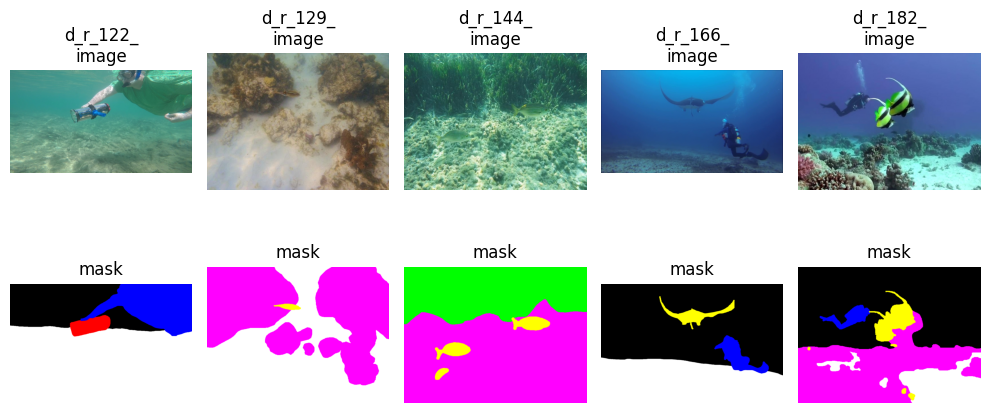

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import os
from PIL import Image

IMG_DIR  = "/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/TEST/images"
MASK_DIR = "/kaggle/working/predictions_raw"

# собираем по пересечению имён
img_paths  = {Path(p).stem: os.path.join(IMG_DIR, p)
              for p in sorted(os.listdir(IMG_DIR))
              if p.lower().endswith((".png", ".jpg", ".bmp"))}

mask_paths = {Path(p).stem: os.path.join(MASK_DIR, p)
              for p in sorted(os.listdir(MASK_DIR))
              if p.lower().endswith((".png", ".jpg", ".bmp"))}

common = sorted(set(img_paths.keys()) & set(mask_paths.keys()))
print(f"Общих файлов: {len(common)}")

# покажем первые 5
plt.figure(figsize=(10, 5))
for i, stem in enumerate(common[:5]):
    img  = Image.open(img_paths[stem])
    mask = Image.open(mask_paths[stem])

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{stem}\nimage")

    plt.subplot(2, 5, i+6)
    plt.imshow(mask)
    plt.axis("off")
    plt.title("mask")

plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
from torch.utils.data import DataLoader

def make_local_test_loader(img_dir, mask_dir, batch_size=16, shuffle=False):
    img_paths  = {Path(p).stem: os.path.join(img_dir, p)
                  for p in sorted(os.listdir(img_dir))
                  if p.lower().endswith((".png", ".jpg", ".jpeg"))}
    mask_paths = {Path(p).stem: os.path.join(mask_dir, p)
                  for p in sorted(os.listdir(mask_dir))
                  if p.lower().endswith((".png", ".jpg", ".bmp"))}

    common = sorted(set(img_paths.keys()) & set(mask_paths.keys()))
    assert common, "Нет пересечения имён между images и masks"

    images = [img_paths[k]  for k in common]
    masks  = [mask_paths[k] for k in common]
    print(f"[LOCAL TEST] найдено пар: {len(common)}")

    dataset = UnderwaterDataset(images, masks)  # используем твой класс (та же preprocess_mask/трансформы)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader


In [ ]:
local_test_loader = make_local_test_loader(
    IMG_DIR,
    MASK_DIR,
    batch_size=64,
    shuffle=False
)


[LOCAL TEST] найдено пар: 110


In [ ]:
import torch
import torch.nn.functional as F

def evaluate_on_loader(model, loader, n_classes=8, up_size=(256,256), device="cuda"):
    model.eval()
    miou_sum, acc_sum, n = 0.0, 0.0, 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs  = imgs.to(device)
            masks = masks.to(device).long()                 # классы 0..7

            H, W  = imgs.shape[-2:]
            imgsU = F.interpolate(imgs, size=up_size, mode="bilinear", align_corners=False)

            out = model(imgsU)
            if isinstance(out, dict):
                out = out["out"]  # (N,C,256,256)

            # Приводим логиты к размеру маски (H,W) и отдаём их в метрики
            out_dw = F.interpolate(out, size=(H, W), mode="bilinear", align_corners=False)

            miou_sum += mIoU(out_dw, masks, n_classes=n_classes)
            acc_sum  += pixel_accuracy(out_dw, masks)
            n += 1

    miou = miou_sum / max(n, 1)
    acc  = acc_sum  / max(n, 1)
    print(f"[EVAL] mIoU={miou:.4f} | Acc={acc:.4f}")
    return miou, acc


In [ ]:
evaluate_on_loader(model, local_test_loader, n_classes=8, device=device)


[EVAL] mIoU=0.6465 | Acc=0.8555


(np.float64(0.6465034971167014), 0.8554811477661133)

In [ ]:
import os
import numpy as np
from PIL import Image
from pathlib import Path

SRC = MASK_DIR         # RGB-маски
DST = "/kaggle/working/predictions_raw"     # сюда сложим индексные маски (0..7)
os.makedirs(DST, exist_ok=True)

def rgb_to_index_mask(pil_img):
    # вход: PIL RGB/PNG с цветами классов
    arr = np.array(pil_img)                  # (H,W,3)
    # бинаризуем каналы: >100 — как в твоём preprocess_mask
    bin3 = (arr > 100).astype(np.uint8)      # (H,W,3) в {0,1}
    idx  = np.dot(bin3, [4, 2, 1]).astype(np.uint8)  # 0..7
    return Image.fromarray(idx, mode="L")    # одноканальная маска индексов

for name in sorted(os.listdir(SRC)):
    if not name.lower().endswith((".png", ".jpg", "bmp")):
        continue
    src_path = os.path.join(SRC, name)
    dst_path = os.path.join(DST, Path(name).with_suffix(".png").name)
    m = Image.open(src_path).convert("RGB")
    rgb_to_index_mask(m).save(dst_path)
print("Готово: индексные маски сохранены в", DST)


/tmp/ipython-input-1208951692.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(idx, mode="L")    # одноканальная маска индексов


Готово: индексные маски сохранены в /kaggle/working/predictions_raw


In [ ]:
import os, numpy as np
from PIL import Image
from pathlib import Path

IMG_MASK_DIR = MASK_DIR     # RGB-маски

def preprocess_mask_ref(mask_pil):
    mask = np.array(mask_pil)
    mask = (mask > 100)
    return np.dot(mask, [4,2,1]).astype(np.uint8)   # эталон из твоего кода

def rgb_to_index_mask(mask_pil):
    arr = np.array(mask_pil)
    bin3 = (arr > 100).astype(np.uint8)
    return np.dot(bin3, [4,2,1]).astype(np.uint8)   # наш конвертер (то же самое)

names = [p for p in sorted(os.listdir(IMG_MASK_DIR)) if p.lower().endswith((".png",".jpg",".bmp"))][:5]
for name in names:
    m = Image.open(os.path.join(IMG_MASK_DIR, name)).convert("RGB")
    ref = preprocess_mask_ref(m)
    got = rgb_to_index_mask(m)

    same = np.array_equal(ref, got)
    uniq = np.unique(got)
    print(f"{name}: equal={same}, unique={uniq}, min={got.min()}, max={got.max()}")


d_r_122_.bmp: equal=True, unique=[0 1 4 7], min=0, max=7
d_r_129_.bmp: equal=True, unique=[5 6 7], min=5, max=7
d_r_144_.bmp: equal=True, unique=[2 5 6], min=2, max=6
d_r_166_.bmp: equal=True, unique=[0 1 6 7], min=0, max=7
d_r_182_.bmp: equal=True, unique=[0 1 5 6 7], min=0, max=7


0 - фон, черный

1 - человек, синий

2 - растения, зеленый

3 - руины, циан

4 - роботы, красный

5 - рифы, розовый

6 - рыбы, желтый

7 - дно, белый

In [ ]:
import numpy as np
from PIL import Image

mask = np.array(Image.open("/kaggle/input/datasets/ashish2001/semantic-segmentation-of-underwater-imagery-suim/test/masks_idx/d_r_122_.png"))
print("shape:", mask.shape, "dtype:", mask.dtype)
print("уникальные значения:", np.unique(mask))

shape: (540, 960) dtype: uint8
уникальные значения: [0 1 4 7]


In [ ]:
import os, numpy as np
from pathlib import Path
from PIL import Image

def export_masks_idx_to_txt(masks_dir, outfile="submission_from_masks.txt", limit=64):
    # соберём и отсортируем файлы; возьмём ровно limit штук
    names = sorted([p for p in os.listdir(masks_dir)
                    if p.lower().endswith((".png",".jpg",".jpeg"))])[:limit]
    assert len(names) == limit, f"Нужно ровно {limit} масок, найдено {len(names)}"

    labels = []
    for name in names:
        m = Image.open(os.path.join(masks_dir, name))
        if m.mode != "L": m = m.convert("L")          # индексы классов (0..7)
        # привести к 128×128 без смешивания классов
        m = m.resize((128,128), resample=Image.NEAREST)
        labels.append(np.array(m, dtype=np.uint8))

    labels = np.stack(labels, axis=0)                 # (N,128,128)

    # пишем в txt как в сабмите
    with open(outfile, "w") as f:
        f.write(f"# Array shape: {labels.shape}\n")
        for sl in labels:
            np.savetxt(f, sl, fmt="%d")
            f.write("# New slice\n")
    print(f"Готово: {outfile}")

# пример вызова:
export_masks_idx_to_txt("/kaggle/working/predictions_raw", "submission_from_masks.txt", limit=64)


Готово: submission_from_masks.txt


In [ ]:
# наш сабмит vs экспорт из masks_idx
predicted_labels = get_predictions(model)
labels = np.stack(predicted_labels, axis=0).astype(np.uint8)  # (N,128,128)
save_submission(labels, "submission.txt")
compare_submissions("submission.txt", "submission_from_masks.txt", n_classes=8)


Ответ сохранен в файл submission.txt. Теперь можно отправить его в Яндекс Контекст!
[COMPARE] shape=(64, 128, 128), pixels=1048576
[COMPARE] Pixel Acc = 0.8480
[COMPARE] mIoU      = 0.5848
[COMPARE] IoU per class: C0:0.888, C1:0.734, C2:0.094, C3:0.315, C4:0.651, C5:0.687, C6:0.659, C7:0.650


(np.float64(0.8480138778686523),
 np.float64(0.5848036429752366),
 [np.float64(0.8875061753972174),
  np.float64(0.7340080781514183),
  np.float64(0.09429482105803581),
  np.float64(0.31530742274609747),
  np.float64(0.6509509349528528),
  np.float64(0.6870463388244399),
  np.float64(0.658862845964353),
  np.float64(0.6504525267074781)])

In [ ]:
num_epochs = 1
best_miou = -1.0
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, num_epochs+1):
    model.train()
    train_loss, train_acc, train_miou = 0.0, 0.0, 0.0
    n_batches = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - train", leave=False):
        imgs = imgs.to(device)
        # твой датасет возвращает маски с числами 0..7 (float); приводим к long
        masks_long = masks.to(device).long()

        optimizer.zero_grad(set_to_none=True)
        out = model(imgs)["out"]               # [B, 8, H, W]
        loss = criterion(out, masks_long)      # CE ждёт long-индексы классов
        loss.backward()
        optimizer.step()

        # метрики
        acc = pixel_accuracy(out.detach(), masks_long)
        miou = mIoU(out.detach(), masks_long, n_classes=8)

        train_loss += loss.item()
        train_acc  += acc
        train_miou += miou
        n_batches  += 1

    train_loss /= n_batches
    train_acc  /= n_batches
    train_miou /= n_batches

    # --- валидация ---
    model.eval()
    val_loss, val_acc, val_miou = 0.0, 0.0, 0.0
    n_batches = 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} - val", leave=False):
            imgs = imgs.to(device)
            masks_long = masks.to(device).long()

            out = model(imgs)["out"]
            loss = criterion(out, masks_long)

            acc = pixel_accuracy(out, masks_long)
            miou = mIoU(out, masks_long, n_classes=8)

            val_loss += loss.item()
            val_acc  += acc
            val_miou += miou
            n_batches += 1

    val_loss /= n_batches
    val_acc  /= n_batches
    val_miou /= n_batches

    scheduler.step(val_miou)

    print(f"[{epoch:02d}] "
          f"train: loss={train_loss:.4f}, acc={train_acc:.4f}, mIoU={train_miou:.4f} | "
          f"val: loss={val_loss:.4f}, acc={val_acc:.4f}, mIoU={val_miou:.4f}")

    # сохраняем лучший чекпоинт по mIoU
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save(model.state_dict(), "checkpoints/best_deeplabv3_resnet50_8cls.pth")
        print(f"✔ best mIoU improved to {best_miou:.4f}, checkpoint saved.")


Epoch 1/1 - train:   0%|          | 0/77 [00:00<?, ?it/s]

Epoch 1/1 - val:   0%|          | 0/20 [00:00<?, ?it/s]

[01] train: loss=0.2602, acc=0.9196, mIoU=0.7684 | val: loss=0.2601, acc=0.9213, mIoU=0.7673
✔ best mIoU improved to 0.7673, checkpoint saved.
